# Intel Berkeley Research Lab IoT-Enhanced Process Mining Pipeline

This notebook demonstrates the complete pipeline for analyzing sensor network data from the Intel Berkeley Research Lab. The pipeline includes:

1. **Data Loading & Exploration**: Load raw sensor data and understand its structure
2. **Data Quality Detection**: Identify noise, missing values, drift, and anomalies
3. **Event Abstraction**: Transform sensor patterns into high-level process events

The dataset captures sensor readings (temperature, humidity, light, voltage) from 54 motes deployed in a research lab over several weeks in 2004.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the Intel Berkeley Research Lab dataset
# Format: timestamp mote_id epoch temperature humidity light voltage
data_path = '../../data/Intel Berkeley Research Lab Sensor Data/data.txt'

print("📂 Loading Intel Berkeley sensor data...")
print("   This may take a moment (2.3M readings)...\n")

# Read the data with space separator
column_names = ['date', 'time', 'mote_id', 'epoch', 'temperature', 'humidity', 'light', 'voltage']
df = pd.read_csv(data_path, sep='\s+', names=column_names, header=None)

# Combine date and time into timestamp
# Use format='mixed' to handle inconsistent datetime formats (with/without microseconds)
df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='mixed')
df = df.drop(['date', 'time'], axis=1)

# Reorder columns
df = df[['timestamp', 'mote_id', 'epoch', 'temperature', 'humidity', 'light', 'voltage']]

# Sort by timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"✅ Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"Number of motes: {df['mote_id'].nunique()}")
print(f"Total readings: {len(df):,}")

📂 Loading Intel Berkeley sensor data...
   This may take a moment (2.3M readings)...

✅ Dataset loaded successfully!

Shape: (2313682, 7)
Time range: 2004-02-28 00:58:15.315133 to 2004-04-05 11:02:32.715337
Duration: 37 days 10:04:17.400204
Number of motes: 65536
Total readings: 2,313,682
✅ Dataset loaded successfully!

Shape: (2313682, 7)
Time range: 2004-02-28 00:58:15.315133 to 2004-04-05 11:02:32.715337
Duration: 37 days 10:04:17.400204
Number of motes: 65536
Total readings: 2,313,682


In [3]:
# Display sample data
print("Sample of raw sensor data:\n")
df.head(10)

Sample of raw sensor data:



,timestamp,mote_id,epoch,temperature,humidity,light,voltage
0,2004-02-28 00:58:15.315133,1,NaN,NaN,NaN,NaN,NaN
1,2004-02-28 00:58:46.002832,2,19.0,19.7336,37.0933,71.76000,2.69964
2,2004-02-28 00:58:46.171824,2,25.0,19.6160,37.5737,97.52000,2.69964
3,2004-02-28 00:58:46.206631,2,24.0,19.7728,37.1620,143.52000,2.71196
4,2004-02-28 00:58:46.497331,2,3.0,20.2040,36.8871,50.60000,2.69964
5,2004-02-28 00:58:46.504403,2,28.0,19.0476,40.0945,2.80151,NaN
6,2004-02-28 00:58:46.657464,2,6.0,20.4196,36.6118,121.44000,2.65143
7,2004-02-28 00:58:46.780824,2,26.0,19.4494,39.6200,121.44000,2.69964
8,2004-02-28 00:58:46.876528,2,27.0,20.1354,37.1620,79.12000,2.71196
9,2004-02-28 00:58:46.910403,2,31.0,19.5572,39.0763,150.88000,2.69964


In [4]:
# Basic statistics
print("📊 Sensor Reading Statistics:\n")
df[['temperature', 'humidity', 'light', 'voltage']].describe()

📊 Sensor Reading Statistics:



,temperature,humidity,light,voltage
count,2.313156e+06,2.312783e+06,2.312779e+06,2.219803e+06
mean,3.920103e+01,3.390809e+01,3.909430e+02,2.490634e+00
std,3.741915e+01,1.732155e+01,5.344185e+02,1.784080e-01
min,-3.840000e+01,-8.983130e+03,0.000000e+00,9.100830e-03
25%,2.040980e+01,3.187760e+01,1.840000e+01,2.385220e+00
50%,2.243840e+01,3.928030e+01,1.435200e+02,2.527320e+00
75%,2.701500e+01,4.358550e+01,5.078400e+02,2.627960e+00
max,3.855680e+02,1.375120e+02,1.847360e+03,3.159150e+00



Mote ID distribution (showing first 20):
mote_id
0      6
1      3
2     49
3     32
4     31
5     27
6     27
7     28
8     25
9     25
10    20
11    20
12    20
13    19
14    20
15    24
16    27
17    19
18    32
19    30
Name: count, dtype: int64


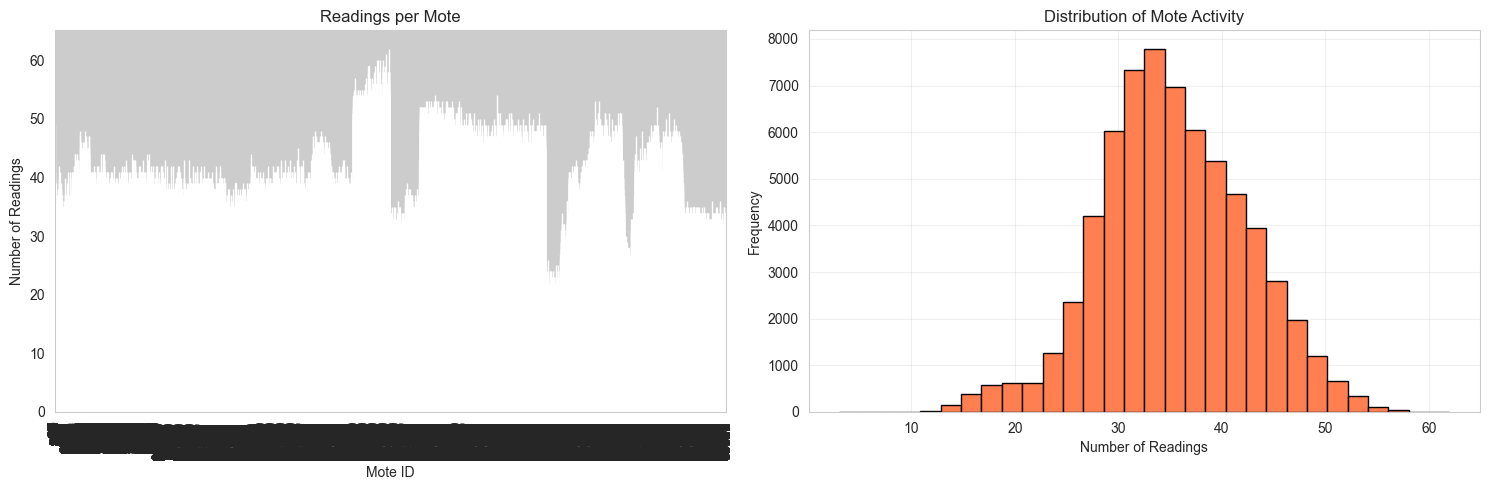


📊 Statistics:
  Average readings per mote: 35
  Median readings per mote: 35
  Min: 3, Max: 62


In [5]:
# Mote distribution
mote_counts = df['mote_id'].value_counts().sort_index()
print(f"\nMote ID distribution (showing first 20):")
print(mote_counts.head(20))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Readings per mote
mote_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_xlabel('Mote ID')
ax1.set_ylabel('Number of Readings')
ax1.set_title('Readings per Mote')
ax1.grid(True, alpha=0.3)

# Distribution of reading counts
ax2.hist(mote_counts.values, bins=30, color='coral', edgecolor='black')
ax2.set_xlabel('Number of Readings')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Mote Activity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistics:")
print(f"  Average readings per mote: {mote_counts.mean():.0f}")
print(f"  Median readings per mote: {mote_counts.median():.0f}")
print(f"  Min: {mote_counts.min()}, Max: {mote_counts.max()}")

📈 Visualizing sensor patterns for selected motes...



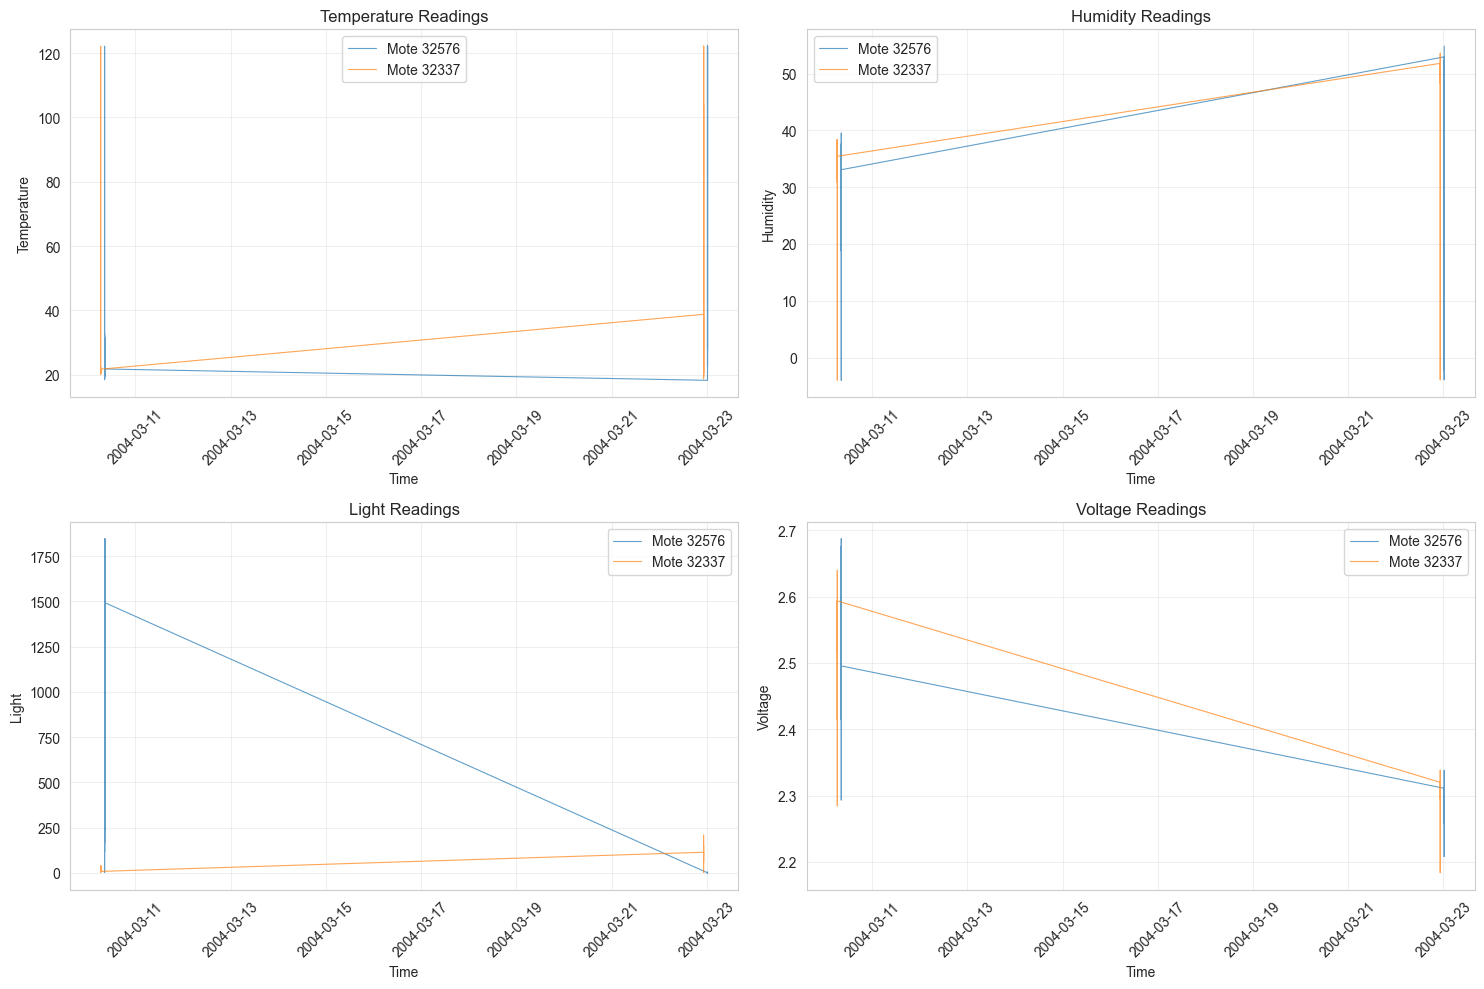

In [6]:
# Visualize sensor readings over time for selected motes
print("📈 Visualizing sensor patterns for selected motes...\n")

# Select 4 motes with good data coverage
top_motes = mote_counts.nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sensors = ['temperature', 'humidity', 'light', 'voltage']
colors = ['red', 'blue', 'orange', 'green']

for idx, sensor in enumerate(sensors):
    ax = axes[idx // 2, idx % 2]
    
    for mote_id in top_motes[:2]:  # Show 2 motes per plot for clarity
        mote_data = df[df['mote_id'] == mote_id].copy()
        # Sample to 1000 points for visualization
        if len(mote_data) > 1000:
            mote_data = mote_data.sample(1000).sort_values('timestamp')
        
        ax.plot(mote_data['timestamp'], mote_data[sensor], 
               label=f'Mote {mote_id}', linewidth=0.8, alpha=0.7)
    
    ax.set_xlabel('Time')
    ax.set_ylabel(sensor.capitalize())
    ax.set_title(f'{sensor.capitalize()} Readings')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 2. Data Quality Detection

We analyze the raw sensor data for quality issues including:
- **Missing values**: Gaps in time series
- **Sensor noise**: Statistical outliers and fluctuations
- **Drift**: Baseline shifts over time
- **Range issues**: Out-of-range values

**Important**: Quality issues are tracked at the **timestamp level**, not globally per sensor.

In [7]:
# Initialize quality issue tracking
quality_issues = []
quality_flags_df = df.copy()

# Add quality flag columns for each sensor
for sensor in ['temperature', 'humidity', 'light', 'voltage']:
    quality_flags_df[f'{sensor}_quality_flag'] = False

print("✓ Quality tracking initialized")

✓ Quality tracking initialized


In [8]:
def detect_missing_values(df, quality_flags_df):
    """Detect missing or NaN values in the dataset"""
    issues = []
    sensors = ['temperature', 'humidity', 'light', 'voltage']
    
    for sensor in sensors:
        missing = df[sensor].isnull()
        missing_count = missing.sum()
        
        if missing_count > 0:
            # Mark missing values
            quality_flags_df.loc[missing, f'{sensor}_quality_flag'] = True
            
            issues.append({
                'type': 'missing_value',
                'sensor': sensor,
                'count': int(missing_count),
                'percentage': missing_count / len(df) * 100
            })
    
    return issues

def detect_sensor_noise(df, quality_flags_df, z_threshold=2.5):
    """Detect statistical outliers using z-score"""
    issues = []
    sensors = ['temperature', 'humidity', 'light', 'voltage']
    
    for sensor in sensors:
        values = df[sensor].dropna()
        
        if len(values) > 0:
            z_scores = np.abs(stats.zscore(values))
            outlier_mask = z_scores > z_threshold
            
            # Mark outlier timestamps
            outlier_indices = values[outlier_mask].index
            quality_flags_df.loc[outlier_indices, f'{sensor}_quality_flag'] = True
            
            outliers = np.sum(outlier_mask)
            if outliers > 0:
                issues.append({
                    'type': 'sensor_noise',
                    'sensor': sensor,
                    'outlier_count': int(outliers),
                    'percentage': outliers / len(df) * 100,
                    'outlier_indices': outlier_indices.tolist()[:100]  # Store first 100
                })
    
    return issues

def detect_sampling_gaps(df, quality_flags_df):
    """Detect large gaps in sampling per mote"""
    issues = []
    
    for mote_id in df['mote_id'].unique():
        mote_data = df[df['mote_id'] == mote_id].sort_values('timestamp')
        
        if len(mote_data) < 2:
            continue
        
        time_diffs = mote_data['timestamp'].diff().dt.total_seconds()
        median_interval = time_diffs.median()
        
        # Gaps larger than 10x median interval (relaxed threshold)
        large_gaps = time_diffs[time_diffs > median_interval * 10]
        
        if len(large_gaps) > len(time_diffs) * 0.20:  # >20% gaps (relaxed threshold)
            issues.append({
                'type': 'sampling_gap',
                'mote_id': int(mote_id),
                'gap_count': int(len(large_gaps)),
                'max_gap_seconds': float(large_gaps.max()),
                'percentage': len(large_gaps) / len(time_diffs) * 100
            })
    
    return issues

print("✓ Quality detection functions defined")

✓ Quality detection functions defined


In [9]:
# Run quality detection
print("🔍 Running data quality detection...\n")

# Detect missing values
missing_issues = detect_missing_values(df, quality_flags_df)
quality_issues.extend(missing_issues)
print(f"Missing value issues: {len(missing_issues)}")
for issue in missing_issues:
    print(f"  • {issue['sensor']}: {issue['count']} missing ({issue['percentage']:.2f}%)")

# Detect sensor noise
noise_issues = detect_sensor_noise(df, quality_flags_df)
quality_issues.extend(noise_issues)
print(f"\nSensor noise issues: {len(noise_issues)}")
for issue in noise_issues:
    print(f"  • {issue['sensor']}: {issue['outlier_count']} outliers ({issue['percentage']:.2f}%)")

# Detect sampling gaps
gap_issues = detect_sampling_gaps(df, quality_flags_df)
quality_issues.extend(gap_issues)
print(f"\nSampling gap issues: {len(gap_issues)}")
if len(gap_issues) > 0:
    print(f"  (Showing first 5 motes with gaps)")
    for issue in gap_issues[:5]:
        print(f"  • Mote {issue['mote_id']}: {issue['gap_count']} gaps ({issue['percentage']:.1f}%)")

print(f"\n📋 Total quality issues detected: {len(quality_issues)}")

# Count flagged timestamps
total_flagged = 0
for sensor in ['temperature', 'humidity', 'light', 'voltage']:
    sensor_flagged = quality_flags_df[f'{sensor}_quality_flag'].sum()
    total_flagged += sensor_flagged
    print(f"  • {sensor}: {sensor_flagged:,} flagged timestamps")

print(f"\n📍 Total timestamp-level quality flags: {total_flagged:,}")

🔍 Running data quality detection...

Missing value issues: 4
  • temperature: 526 missing (0.02%)
  • humidity: 899 missing (0.04%)
  • light: 903 missing (0.04%)
  • voltage: 93879 missing (4.06%)

Sensor noise issues: 4
  • temperature: 4 outliers (0.00%)
  • humidity: 3923 outliers (0.17%)
  • light: 155726 outliers (6.73%)
  • voltage: 16919 outliers (0.73%)

Sampling gap issues: 564
  (Showing first 5 motes with gaps)
  • Mote 2: 16 gaps (32.7%)
  • Mote 3: 15 gaps (46.9%)
  • Mote 7: 12 gaps (42.9%)
  • Mote 8: 7 gaps (28.0%)
  • Mote 9: 6 gaps (24.0%)

📋 Total quality issues detected: 572
  • temperature: 530 flagged timestamps
  • humidity: 4,822 flagged timestamps
  • light: 156,629 flagged timestamps
  • voltage: 110,798 flagged timestamps

📍 Total timestamp-level quality flags: 272,779

Sampling gap issues: 564
  (Showing first 5 motes with gaps)
  • Mote 2: 16 gaps (32.7%)
  • Mote 3: 15 gaps (46.9%)
  • Mote 7: 12 gaps (42.9%)
  • Mote 8: 7 gaps (28.0%)
  • Mote 9: 6 gaps 

In [10]:
# Display quality issues summary
if len(quality_issues) > 0:
    quality_df = pd.DataFrame(quality_issues)
    print("\n⚠️ Data Quality Issues Summary:\n")
    print(quality_df.to_string())
    
    print("\n\nIssues by type:")
    print(quality_df['type'].value_counts())
else:
    print("✅ No major quality issues detected")


⚠️ Data Quality Issues Summary:

              type       sensor    count  percentage  outlier_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    outlier_indices

## 3. Event Abstraction

Transform raw sensor patterns into **lab activity process events** based on the Intel Berkeley Research Lab context:

**Dataset Context** (from README):
- 54 Mica2Dot sensors deployed in Intel Berkeley Research Lab
- Sampling every 31 seconds (Feb 28 - Apr 5, 2004)
- Light scale: 1 Lux = moonlight, 400 Lux = bright office, 100,000 Lux = sunlight
- TinyDB in-network query processing system monitoring

**Process Model**: Daily lab operations as cases
- **Lab Opening**: First coordinated light increase (morning)
- **Occupancy Periods**: High/Low occupancy based on coordinated light patterns across motes
  - High Occupancy: >200 Lux (bright office environment)
  - Low Occupancy: 50-200 Lux (some activity/dim lighting)
  - Unoccupied: <50 Lux (dark/minimal activity)
- **Environmental Changes**: HVAC state changes (heating/cooling/normal)
- **Lab Closing**: Last significant activity (evening)

**Quality Propagation**: Sensor quality flags propagate to events detected in affected time windows.

In [11]:
# Define sensor thresholds for event detection based on data percentiles
# Context from README: 1 Lux = moonlight, 400 Lux = bright office, 100,000 Lux = full sunlight
print("📊 Calculating context-aware thresholds from sensor distributions...\n")
print("Context: Intel Berkeley Research Lab (Feb-Apr 2004)")
print("  - Light: 1 Lux = moonlight, 400 Lux = bright office")
print("  - Sampling: Every 31 seconds from 54 Mica2Dot sensors")
print("  - Purpose: TinyDB query processing system monitoring\n")

# Calculate percentile-based thresholds
THRESHOLDS = {
    'temperature': {
        'cold': df['temperature'].quantile(0.25),
        'warm': df['temperature'].quantile(0.75)
    },
    'light': {
        'dark': 50,      # Below typical indoor lighting (office ~400 Lux)
        'bright': 200    # Above ambient but below bright office
    },
    'humidity': {
        'low': df['humidity'].quantile(0.25),
        'high': df['humidity'].quantile(0.75)
    }
}

print("✓ Event detection thresholds calculated")
print("\nContext-Aware Thresholds:")
print(f"  Temperature (percentile-based):")
print(f"    - Cold: {THRESHOLDS['temperature']['cold']:.1f}°C (25th percentile)")
print(f"    - Warm: {THRESHOLDS['temperature']['warm']:.1f}°C (75th percentile)")
print(f"  Light (context-based):")
print(f"    - Dark: {THRESHOLDS['light']['dark']} Lux (unoccupied)")
print(f"    - Bright: {THRESHOLDS['light']['bright']} Lux (occupied/activity)")
print(f"  Humidity (percentile-based):")
print(f"    - Low: {THRESHOLDS['humidity']['low']:.1f}% (25th percentile)")
print(f"    - High: {THRESHOLDS['humidity']['high']:.1f}% (75th percentile)")

📊 Calculating context-aware thresholds from sensor distributions...

Context: Intel Berkeley Research Lab (Feb-Apr 2004)
  - Light: 1 Lux = moonlight, 400 Lux = bright office
  - Sampling: Every 31 seconds from 54 Mica2Dot sensors
  - Purpose: TinyDB query processing system monitoring

✓ Event detection thresholds calculated

Context-Aware Thresholds:
  Temperature (percentile-based):
    - Cold: 20.4°C (25th percentile)
    - Warm: 27.0°C (75th percentile)
  Light (context-based):
    - Dark: 50 Lux (unoccupied)
    - Bright: 200 Lux (occupied/activity)
  Humidity (percentile-based):
    - Low: 31.9% (25th percentile)
    - High: 43.6% (75th percentile)


In [13]:
def abstract_events_from_sensors(df, quality_flags_df, sample_days=14):
    """
    Abstract events from sensor readings modeling lab activity patterns.
    Context: Intel Berkeley Research Lab with 54 Mica2Dot sensors sampling every 31s.
    Process: Daily lab operations with office hours (work periods) and after-hours.
    """
    events = []
    
    # Work with first N days
    start_date = df['timestamp'].min()
    end_date = start_date + timedelta(days=sample_days)
    df_sample = df[df['timestamp'] <= end_date].copy()
    
    print(f"Processing {len(df_sample):,} readings from {sample_days} days...")
    print(f"Modeling lab activity: office hours, occupancy, environmental conditions")
    
    # Add temporal features
    df_sample['day'] = df_sample['timestamp'].dt.date
    df_sample['hour'] = df_sample['timestamp'].dt.hour
    df_sample['is_work_hours'] = (df_sample['hour'] >= 8) & (df_sample['hour'] < 18)
    df_sample['is_weekday'] = df_sample['timestamp'].dt.dayofweek < 5
    
    # Process each day as a case (representing one operational cycle)
    for day in df_sample['day'].unique():
        day_data = df_sample[df_sample['day'] == day].copy()
        case_id = f"Lab_{day}"
        
        # Detect lab opening (first significant light increase during work hours)
        opening_event = detect_lab_opening(day_data, quality_flags_df, case_id)
        if opening_event:
            events.append(opening_event)
        
        # Detect occupancy periods based on coordinated light levels
        occupancy_events = detect_occupancy_periods(day_data, quality_flags_df, case_id)
        events.extend(occupancy_events)
        
        # Detect environmental state changes (HVAC, heating/cooling patterns)
        env_events = detect_environmental_changes(day_data, quality_flags_df, case_id)
        events.extend(env_events)
        
        # Detect lab closing (last significant activity)
        closing_event = detect_lab_closing(day_data, quality_flags_df, case_id)
        if closing_event:
            events.append(closing_event)
    
    return pd.DataFrame(events)

def detect_lab_opening(day_data, quality_flags_df, case_id):
    """Detect when the lab opens (first significant light increase in morning)"""
    # Focus on morning hours (6 AM - 11 AM)
    morning_data = day_data[(day_data['hour'] >= 6) & (day_data['hour'] < 11)]
    
    if len(morning_data) == 0:
        return None
    
    # Look for first time when >30% of motes see office-level light (>100 Lux)
    # Group by timestamp and count how many motes see bright light
    brightness_by_time = morning_data.groupby('timestamp').agg({
        'light': lambda x: (x > 100).sum() / len(x) if len(x) > 0 else 0
    })
    
    # Find first timestamp where >30% of motes are bright
    opening_times = brightness_by_time[brightness_by_time['light'] > 0.3]
    
    if len(opening_times) > 0:
        opening_time = opening_times.index[0]
        
        # Check for quality issues in readings around this time
        window_start = opening_time - timedelta(minutes=5)
        window_end = opening_time + timedelta(minutes=5)
        window_readings = day_data[
            (day_data['timestamp'] >= window_start) & 
            (day_data['timestamp'] <= window_end)
        ]
        
        quality_flag = False
        for idx in window_readings.index:
            if idx in quality_flags_df.index:
                if quality_flags_df.loc[idx, 'light_quality_flag']:
                    quality_flag = True
                    break
        
        return {
            'case_id': case_id,
            'activity': 'Lab_Opening',
            'timestamp': opening_time,
            'sensor': 'light',
            'value': brightness_by_time.loc[opening_time, 'light'],
            'quality_flag': quality_flag
        }
    
    return None

def detect_occupancy_periods(day_data, quality_flags_df, case_id):
    """Detect periods of high/low occupancy based on coordinated sensor patterns"""
    events = []
    
    # Resample to 15-minute windows for occupancy detection
    # Reference: 400 Lux = bright office (occupied), <50 Lux = unoccupied
    day_data_indexed = day_data.set_index('timestamp')
    
    occupancy_windows = day_data_indexed.resample('15T').agg({
        'light': ['mean', 'std', 'count'],
        'temperature': 'mean',
        'humidity': 'mean'
    })
    
    for timestamp, row in occupancy_windows.iterrows():
        if row[('light', 'count')] < 5:  # Need sufficient readings
            continue
        
        light_mean = row[('light', 'mean')]
        light_std = row[('light', 'std')]
        temp_mean = row[('temperature', 'mean')]
        
        # Classify occupancy state
        if light_mean > 200:  # Bright office environment
            activity = 'High_Occupancy'
        elif light_mean > 50:  # Some activity/dim lighting
            activity = 'Low_Occupancy'
        else:  # Dark/minimal activity
            activity = 'Unoccupied'
        
        # Check for quality issues in this window
        window_start = timestamp
        window_end = timestamp + timedelta(minutes=15)
        window_readings = day_data[
            (day_data['timestamp'] >= window_start) &             (day_data['timestamp'] < window_end)
        ]
        
        quality_flag = False
        for idx in window_readings.index:
            if idx in quality_flags_df.index:
                if (quality_flags_df.loc[idx, 'light_quality_flag'] or 
                    quality_flags_df.loc[idx, 'temperature_quality_flag']):
                    quality_flag = True
                    break
        
        events.append({
            'case_id': case_id,
            'activity': activity,
            'timestamp': timestamp,
            'sensor': 'light',
            'value': light_mean,
            'quality_flag': quality_flag
        })
    
    return events

def detect_environmental_changes(day_data, quality_flags_df, case_id):
    """Detect HVAC state changes based on temperature and humidity patterns"""
    events = []
    
    # Resample to hourly for environmental state detection
    day_data_indexed = day_data.set_index('timestamp')
    
    env_windows = day_data_indexed.resample('1H').agg({
        'temperature': ['mean', 'std'],
        'humidity': ['mean', 'std']
    })
    
    for timestamp, row in env_windows.iterrows():
        if pd.notna(row[('temperature', 'mean')]):
            temp_mean = row[('temperature', 'mean')]
            humidity_mean = row[('humidity', 'mean')]
            
            # Classify environmental state
            if temp_mean < THRESHOLDS['temperature']['cold']:
                activity = 'HVAC_Heating_Active'
            elif temp_mean > THRESHOLDS['temperature']['warm']:
                activity = 'HVAC_Cooling_Active'
            else:
                activity = 'HVAC_Normal'
            
            # Check for quality issues in this hour
            hour_start = timestamp
            hour_end = timestamp + timedelta(hours=1)
            hour_readings = day_data[
                (day_data['timestamp'] >= hour_start) & 
                (day_data['timestamp'] < hour_end)
            ]
            
            quality_flag = False
            for idx in hour_readings.index:
                if idx in quality_flags_df.index:
                    if (quality_flags_df.loc[idx, 'temperature_quality_flag'] or
                        quality_flags_df.loc[idx, 'humidity_quality_flag']):
                        quality_flag = True
                        break
            
            events.append({
                'case_id': case_id,
                'activity': activity,
                'timestamp': timestamp,
                'sensor': 'temperature',
                'value': temp_mean,
                'quality_flag': quality_flag
            })
    
    return events

def detect_lab_closing(day_data, quality_flags_df, case_id):
    """Detect when the lab closes (last significant activity in evening)"""
    # Focus on evening hours (5 PM - 11 PM)
    evening_data = day_data[(day_data['hour'] >= 17) & (day_data['hour'] < 23)]
    
    if len(evening_data) == 0:
        return None
    
    # Look for last time when >30% of motes see office-level light
    brightness_by_time = evening_data.groupby('timestamp').agg({
        'light': lambda x: (x > 100).sum() / len(x) if len(x) > 0 else 0
    })
    
    # Find last timestamp where >30% of motes are bright
    closing_times = brightness_by_time[brightness_by_time['light'] > 0.3]
    
    if len(closing_times) > 0:
        closing_time = closing_times.index[-1]
        
        # Check for quality issues around closing time
        window_start = closing_time - timedelta(minutes=5)
        window_end = closing_time + timedelta(minutes=5)
        window_readings = day_data[
            (day_data['timestamp'] >= window_start) & 
            (day_data['timestamp'] <= window_end)
        ]
        
        quality_flag = False
        for idx in window_readings.index:
            if idx in quality_flags_df.index:
                if quality_flags_df.loc[idx, 'light_quality_flag']:
                    quality_flag = True
                    break
        
        return {
            'case_id': case_id,
            'activity': 'Lab_Closing',
            'timestamp': closing_time,
            'sensor': 'light',
            'value': brightness_by_time.loc[closing_time, 'light'],
            'quality_flag': quality_flag
        }
    
    return None

print("✓ Event abstraction functions defined")

✓ Event abstraction functions defined


In [14]:
# Abstract events
print("🔄 Abstracting events from sensor patterns...\n")

event_log = abstract_events_from_sensors(df, quality_flags_df, sample_days=14)

# Rename to pm4py standard format
event_log = event_log.rename(columns={
    'case_id': 'case:concept:name',
    'activity': 'concept:name',
    'timestamp': 'time:timestamp'
})

event_log = event_log.sort_values(['case:concept:name', 'time:timestamp']).reset_index(drop=True)

print(f"\n✅ Event abstraction complete!")
print(f"\n📊 Event Log Statistics:")
print(f"  Total events: {len(event_log)}")
print(f"  Total cases: {event_log['case:concept:name'].nunique()}")
print(f"  Unique activities: {event_log['concept:name'].nunique()}")
print(f"  Events with quality flags: {event_log['quality_flag'].sum()}")
print(f"  Quality flag percentage: {event_log['quality_flag'].sum() / len(event_log) * 100:.1f}%")

print(f"\n📍 Quality Flag Verification:")
print(f"  Light events with quality flags: {event_log[event_log['sensor'] == 'light']['quality_flag'].sum()}")
print(f"  Temperature events with quality flags: {event_log[event_log['sensor'] == 'temperature']['quality_flag'].sum()}")

print(f"\n  Activity distribution:")
print(event_log['concept:name'].value_counts())

🔄 Abstracting events from sensor patterns...

Processing 1,219,807 readings from 14 days...
Modeling lab activity: office hours, occupancy, environmental conditions

✅ Event abstraction complete!

📊 Event Log Statistics:
  Total events: 1589
  Total cases: 15
  Unique activities: 8
  Events with quality flags: 611
  Quality flag percentage: 38.5%

📍 Quality Flag Verification:
  Light events with quality flags: 546
  Temperature events with quality flags: 65

  Activity distribution:
concept:name
High_Occupancy         552
Low_Occupancy          515
HVAC_Normal            215
Unoccupied             181
HVAC_Heating_Active     91
Lab_Opening             14
Lab_Closing             13
HVAC_Cooling_Active      8
Name: count, dtype: int64


In [15]:
# Display sample event log
print("\nSample Event Log (first 20 events):\n")
event_log.head(20)


Sample Event Log (first 20 events):



,case:concept:name,concept:name,time:timestamp,sensor,value,quality_flag
0,Lab_2004-02-28,HVAC_Heating_Active,2004-02-28 00:00:00,temperature,19.515471,True
1,Lab_2004-02-28,Low_Occupancy,2004-02-28 00:45:00,light,113.223372,True
2,Lab_2004-02-28,Low_Occupancy,2004-02-28 01:00:00,light,150.232889,False
3,Lab_2004-02-28,HVAC_Heating_Active,2004-02-28 01:00:00,temperature,18.331246,False
4,Lab_2004-02-28,Low_Occupancy,2004-02-28 01:15:00,light,146.616342,False
5,Lab_2004-02-28,Low_Occupancy,2004-02-28 01:30:00,light,133.230316,False
6,Lab_2004-02-28,Low_Occupancy,2004-02-28 01:45:00,light,133.317842,False
7,Lab_2004-02-28,Low_Occupancy,2004-02-28 02:00:00,light,150.973545,False
8,Lab_2004-02-28,HVAC_Heating_Active,2004-02-28 02:00:00,temperature,17.926965,True
9,Lab_2004-02-28,Low_Occupancy,2004-02-28 02:15:00,light,144.560976,True


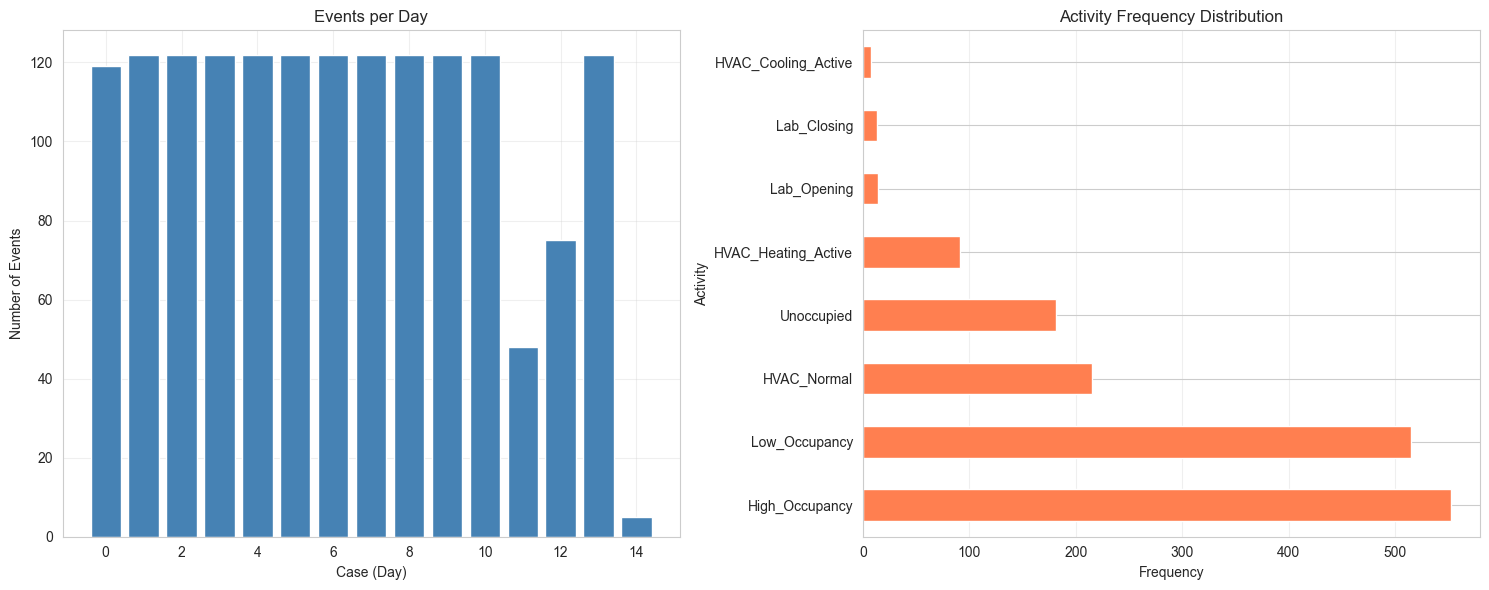

In [16]:
# Visualize event distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Events per case
events_per_case = event_log.groupby('case:concept:name').size()
ax1.bar(range(len(events_per_case)), events_per_case.values, color='steelblue')
ax1.set_xlabel('Case (Day)')
ax1.set_ylabel('Number of Events')
ax1.set_title('Events per Day')
ax1.grid(True, alpha=0.3)

# Activity frequency
activity_counts = event_log['concept:name'].value_counts()
activity_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Activity')
ax2.set_title('Activity Frequency Distribution')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. Process Discovery & Ground Truth Selection

We use pm4py to discover the process model and select a baseline "normal" day for conformance checking.

In [17]:
# Import pm4py
import pm4py

print("✓ pm4py imported successfully")

✓ pm4py imported successfully


In [18]:
# Calculate case quality scores
case_stats = []

for case_id in event_log['case:concept:name'].unique():
    case_events = event_log[event_log['case:concept:name'] == case_id]
    
    case_stats.append({
        'case_id': case_id,
        'num_events': len(case_events),
        'num_quality_issues': case_events['quality_flag'].sum(),
        'quality_ratio': case_events['quality_flag'].sum() / len(case_events) if len(case_events) > 0 else 0,
        'duration': (case_events['time:timestamp'].max() - case_events['time:timestamp'].min()).total_seconds(),
        'unique_activities': case_events['concept:name'].nunique()
    })

case_stats_df = pd.DataFrame(case_stats)

print("Case Statistics Summary:\n")
print(case_stats_df)

Case Statistics Summary:

           case_id  num_events  num_quality_issues  quality_ratio  duration  unique_activities
0   Lab_2004-02-28         119                  56       0.470588   85500.0                  7
1   Lab_2004-02-29         122                  46       0.377049   85500.0                  7
2   Lab_2004-03-01         122                  31       0.254098   85500.0                  6
3   Lab_2004-03-02         122                  53       0.434426   85500.0                  8
4   Lab_2004-03-03         122                  49       0.401639   85500.0                  8
5   Lab_2004-03-04         122                  41       0.336066   85500.0                  7
6   Lab_2004-03-05         122                  44       0.360656   85500.0                  6
7   Lab_2004-03-06         122                  42       0.344262   85500.0                  6
8   Lab_2004-03-07         122                  42       0.344262   85500.0                  7
9   Lab_2004-03-08      

In [19]:
# Select ground truth: day with median event count and low quality issues
median_events = case_stats_df['num_events'].median()
print(f"Median events per day: {median_events:.0f}\n")

# Prioritize low quality ratio and typical event count
candidates = case_stats_df[
    (case_stats_df['num_events'] >= median_events * 0.8) &
    (case_stats_df['num_events'] <= median_events * 1.2)
].copy()

if len(candidates) > 0:
    candidates['distance_from_median'] = np.abs(candidates['num_events'] - median_events)
    candidates = candidates.sort_values(['quality_ratio', 'distance_from_median'])
    ground_truth_case = candidates.iloc[0]['case_id']
    print(f"Selected from {len(candidates)} candidates with typical event count")
else:
    # Fallback: select day with lowest quality ratio
    case_stats_df['distance_from_median'] = np.abs(case_stats_df['num_events'] - median_events)
    case_stats_df_sorted = case_stats_df.sort_values(['quality_ratio', 'distance_from_median'])
    ground_truth_case = case_stats_df_sorted.iloc[0]['case_id']
    print(f"Using fallback selection (no candidates in median range)")

ground_truth_events = event_log[event_log['case:concept:name'] == ground_truth_case].copy()

print(f"\n🎯 Selected Ground Truth Case: {ground_truth_case}")
print(f"\n   Statistics:")
gt_stats = case_stats_df[case_stats_df['case_id'] == ground_truth_case].iloc[0]
print(f"   - Number of events: {gt_stats['num_events']}")
print(f"   - Quality issues: {gt_stats['num_quality_issues']}")
print(f"   - Quality ratio: {gt_stats['quality_ratio']:.1%}")
print(f"   - Duration: {gt_stats['duration']:.1f} seconds")
print(f"   - Unique activities: {gt_stats['unique_activities']}")

print(f"\n   Event sequence:")
for idx, row in ground_truth_events.iterrows():
    flag = "⚠️" if row['quality_flag'] else "✓"
    print(f"   {flag} {row['concept:name']}")

Median events per day: 122

Selected from 12 candidates with typical event count

🎯 Selected Ground Truth Case: Lab_2004-03-01

   Statistics:
   - Number of events: 122
   - Quality issues: 31
   - Quality ratio: 25.4%
   - Duration: 85500.0 seconds
   - Unique activities: 6

   Event sequence:
   ✓ Low_Occupancy
   ✓ HVAC_Heating_Active
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ HVAC_Heating_Active
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ⚠️ HVAC_Heating_Active
   ⚠️ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ⚠️ HVAC_Heating_Active
   ⚠️ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ HVAC_Heating_Active
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ⚠️ HVAC_Heating_Active
   ⚠️ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ✓ Low_Occupancy
   ⚠️ HVAC_Heating_Active
   ✓ Lab_Opening
   ✓ Low_Occupancy
   ✓ Low_O

In [ ]:
# Visualize ground truth trace
# fig, ax = plt.subplots(figsize=(15, 6))

# gt_events = ground_truth_events.copy()
# gt_events['time_offset'] = (gt_events['time:timestamp'] - gt_events['time:timestamp'].min()).dt.total_seconds()

# for idx, (i, row) in enumerate(gt_events.iterrows()):
#     color = 'red' if row['quality_flag'] else 'green'
#     ax.scatter(row['time_offset'], idx, c=color, s=100, zorder=3)
#     ax.text(row['time_offset'], idx, f"  {row['concept:name']}", 
#             va='center', ha='left', fontsize=8)

# ax.set_xlabel('Time (seconds from day start)')
# ax.set_ylabel('Event Sequence')
# ax.set_title(f'Ground Truth Baseline: {ground_truth_case}', fontweight='bold')
# ax.grid(True, alpha=0.3)

# # Add legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor='green', label='Normal Event'),
#     Patch(facecolor='red', label='Quality Issue')
# ]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
# plt.show()

🔍 Discovering process model from ground truth case...

✅ Process model discovered!
   Places: 14
   Transitions: 20
   Arcs: 42

📊 Ground Truth Petri Net:


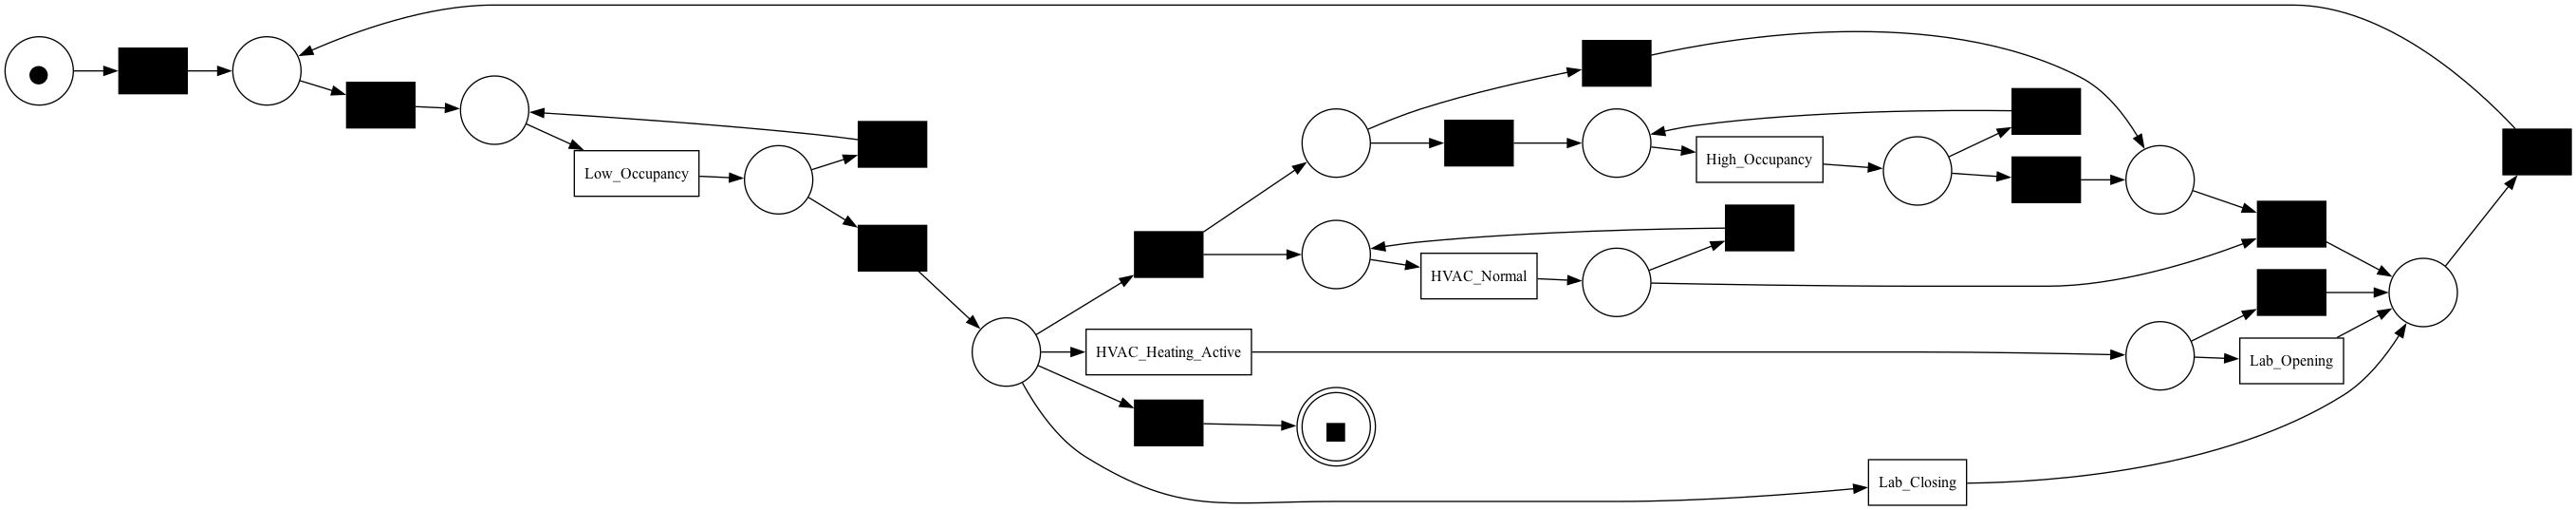

In [20]:
# Discover process model using pm4py Inductive Miner
print("🔍 Discovering process model from ground truth case...\n")

# Create event log from ground truth case only
ground_truth_log = ground_truth_events[['case:concept:name', 'concept:name', 'time:timestamp']].copy()

# Discover Petri net using Inductive Miner
net_groundtruth, im_groundtruth, fm_groundtruth = pm4py.discover_petri_net_inductive(ground_truth_log)

print(f"✅ Process model discovered!")
print(f"   Places: {len(net_groundtruth.places)}")
print(f"   Transitions: {len(net_groundtruth.transitions)}")
print(f"   Arcs: {len(net_groundtruth.arcs)}")

# Visualize the Petri net
print("\n📊 Ground Truth Petri Net:")
pm4py.view_petri_net(net_groundtruth, im_groundtruth, fm_groundtruth)

# Ground truth fitness is 1.0 by definition (perfect conformance to itself)
ground_truth_fitness = 1.0

## 5. Conformance Checking with pm4py

Compare each day against the ground truth model using token-based replay:
- **Trace fitness**: How well each trace conforms to the discovered model
- **Conformance diagnostics**: Detailed information about missing/consumed tokens
- **Deviations**: Identify which activities don't fit the expected process

In [21]:
# Calculate conformance for all cases using pm4py token-based replay
print("⚖️ Calculating conformance using pm4py token-based replay...\n")

# Get fitness for all traces
fitness_results = pm4py.fitness_token_based_replay(event_log, net_groundtruth, im_groundtruth, fm_groundtruth)

print(f"✅ Conformance checking complete!\n")
print(f"📊 Overall Fitness Statistics:")
print(f"   Average fitness: {fitness_results['average_trace_fitness']:.3f}")
print(f"   Percentage of fitting traces: {fitness_results['percentage_of_fitting_traces']:.1f}%")
print(f"   Log fitness: {fitness_results['log_fitness']:.3f}")

# Get detailed conformance diagnostics for each trace
diagnostics = pm4py.conformance_diagnostics_token_based_replay(event_log, net_groundtruth, im_groundtruth, fm_groundtruth)

# Get unique case IDs in the same order as they appear in the event log
case_ids = event_log['case:concept:name'].unique()

# Create conformance dataframe from diagnostics
conformance_results = []
for idx, diag in enumerate(diagnostics):
    case_id = case_ids[idx]
    case_events = event_log[event_log['case:concept:name'] == case_id]
    
    conformance_results.append({
        'case_id': case_id,
        'trace_is_fit': diag['trace_is_fit'],
        'fitness': diag['trace_fitness'],
        'missing_tokens': diag['missing_tokens'],
        'consumed_tokens': diag['consumed_tokens'],
        'remaining_tokens': diag['remaining_tokens'],
        'produced_tokens': diag['produced_tokens'],
        'num_events': len(case_events),
        'quality_issues': case_events['quality_flag'].sum()
    })

conformance_df = pd.DataFrame(conformance_results)
conformance_df = conformance_df.sort_values('fitness', ascending=False)

print(f"\n📊 Per-Case Statistics:")
print(f"   Mean fitness: {conformance_df['fitness'].mean():.3f}")
print(f"   Std dev fitness: {conformance_df['fitness'].std():.3f}")
print(f"   Median fitness: {conformance_df['fitness'].median():.3f}")
print(f"   Min fitness: {conformance_df['fitness'].min():.3f}")
print(f"   Max fitness: {conformance_df['fitness'].max():.3f}")
print(f"\n   Cases with perfect fitness (1.0): {len(conformance_df[conformance_df['fitness'] == 1.0])}")
print(f"   Cases with fitness >= 0.8: {len(conformance_df[conformance_df['fitness'] >= 0.8])}")
print(f"   Cases with fitness < 0.5: {len(conformance_df[conformance_df['fitness'] < 0.5])}")

print(f"\n📍 Quality Impact Analysis:")
# Calculate correlation between quality issues and fitness
if len(conformance_df) > 1 and conformance_df['quality_issues'].std() > 0:
    correlation = conformance_df[['quality_issues', 'fitness']].corr().iloc[0, 1]
    print(f"   Correlation (quality issues vs fitness): {correlation:.3f}")
else:
    print(f"   Insufficient variance for correlation analysis")

# Show cases grouped by quality issues
high_quality_cases = conformance_df[conformance_df['quality_issues'] == 0]
low_quality_cases = conformance_df[conformance_df['quality_issues'] > 0]
print(f"   Cases with NO quality issues: {len(high_quality_cases)} (avg fitness: {high_quality_cases['fitness'].mean():.3f})")
print(f"   Cases WITH quality issues: {len(low_quality_cases)} (avg fitness: {low_quality_cases['fitness'].mean():.3f})")

⚖️ Calculating conformance using pm4py token-based replay...



replaying log with TBR, completed traces ::   0%|          | 0/15 [00:00<?, ?it/s]

✅ Conformance checking complete!

📊 Overall Fitness Statistics:
   Average fitness: 0.982
   Percentage of fitting traces: 20.0%
   Log fitness: 0.984


replaying log with TBR, completed traces ::   0%|          | 0/15 [00:00<?, ?it/s]


📊 Per-Case Statistics:
   Mean fitness: 0.982
   Std dev fitness: 0.017
   Median fitness: 0.987
   Min fitness: 0.946
   Max fitness: 1.000

   Cases with perfect fitness (1.0): 3
   Cases with fitness >= 0.8: 15
   Cases with fitness < 0.5: 0

📍 Quality Impact Analysis:
   Correlation (quality issues vs fitness): -0.220
   Cases with NO quality issues: 1 (avg fitness: 1.000)
   Cases WITH quality issues: 14 (avg fitness: 0.981)


In [22]:
# Display conformance results
print("\nConformance Results:\n")
conformance_df[['case_id', 'fitness', 'missing_tokens', 'consumed_tokens', 'num_events', 'quality_issues']]


Conformance Results:



,case_id,fitness,missing_tokens,consumed_tokens,num_events,quality_issues
2,Lab_2004-03-01,1.000000,0,297,122,31
6,Lab_2004-03-05,1.000000,0,293,122,44
14,Lab_2004-03-13,1.000000,0,19,5,0
9,Lab_2004-03-08,0.994656,1,280,122,45
7,Lab_2004-03-06,0.994417,1,268,122,42
8,Lab_2004-03-07,0.994223,1,259,122,42
10,Lab_2004-03-09,0.993140,1,218,122,44
13,Lab_2004-03-12,0.987219,2,195,122,58
0,Lab_2004-02-28,0.980315,5,254,119,56
12,Lab_2004-03-11,0.980000,3,150,75,51


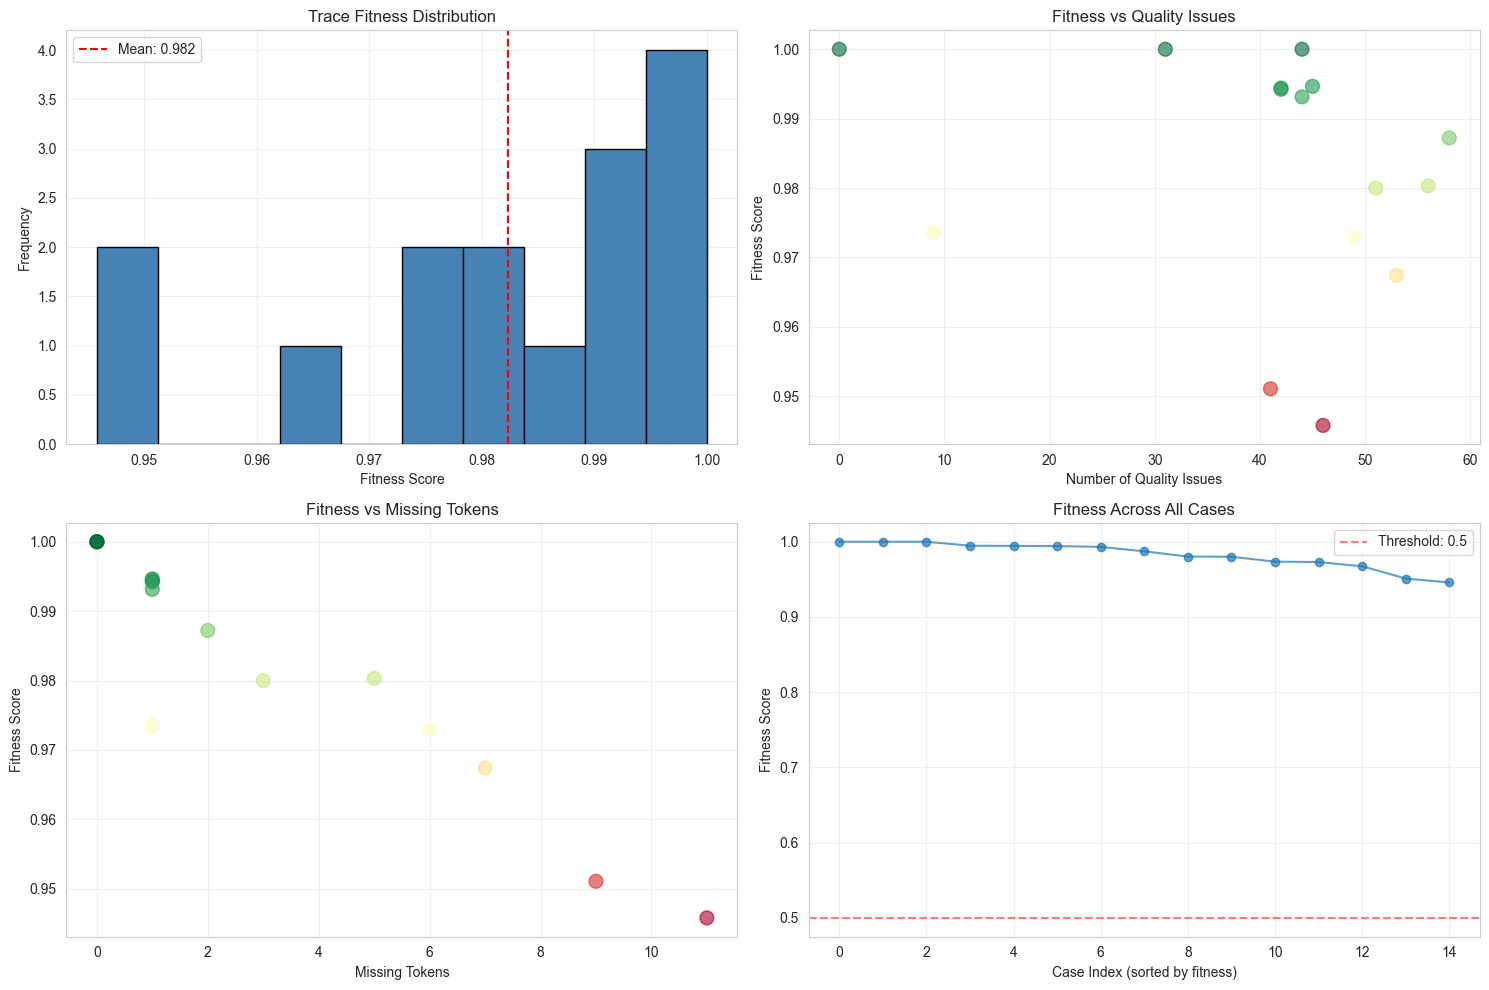

In [23]:
# Visualize conformance distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fitness distribution
axes[0, 0].hist(conformance_df['fitness'], bins=10, color='steelblue', edgecolor='black')
axes[0, 0].axvline(conformance_df['fitness'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {conformance_df["fitness"].mean():.3f}')
axes[0, 0].set_xlabel('Fitness Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Trace Fitness Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Fitness vs Quality Issues
axes[0, 1].scatter(conformance_df['quality_issues'], conformance_df['fitness'], 
                   alpha=0.6, s=100, c=conformance_df['fitness'], cmap='RdYlGn')
axes[0, 1].set_xlabel('Number of Quality Issues')
axes[0, 1].set_ylabel('Fitness Score')
axes[0, 1].set_title('Fitness vs Quality Issues')
axes[0, 1].grid(True, alpha=0.3)

# Fitness vs Missing Tokens
axes[1, 0].scatter(conformance_df['missing_tokens'], conformance_df['fitness'],
                   alpha=0.6, s=100, c=conformance_df['fitness'], cmap='RdYlGn')
axes[1, 0].set_xlabel('Missing Tokens')
axes[1, 0].set_ylabel('Fitness Score')
axes[1, 0].set_title('Fitness vs Missing Tokens')
axes[1, 0].grid(True, alpha=0.3)

# Fitness over cases
axes[1, 1].plot(range(len(conformance_df)), conformance_df['fitness'].values, 
                marker='o', linestyle='-', markersize=6, alpha=0.7)
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Threshold: 0.5')
axes[1, 1].set_xlabel('Case Index (sorted by fitness)')
axes[1, 1].set_ylabel('Fitness Score')
axes[1, 1].set_title('Fitness Across All Cases')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Backtracking & Root Cause Analysis

For cases with low conformance, we trace deviations back to their root causes in the sensor data.
This demonstrates the core capability of the framework: linking process-level issues to data quality problems.

In [24]:
# Select a case for detailed analysis
# Prioritize cases with deviations (fitness < 1.0) and some quality issues
analysis_candidates = conformance_df[
    (conformance_df['fitness'] < 1.0) & 
    (conformance_df['quality_issues'] > 0)
].sort_values('fitness')

if len(analysis_candidates) > 0:
    target_case = analysis_candidates.iloc[0]
    print(f"🔍 Analyzing Case with Deviations: {target_case['case_id']}")
    print(f"   Fitness: {target_case['fitness']:.3f}")
    print(f"   Quality Issues: {target_case['quality_issues']}")
else:
    # Fallback: select the case with lowest fitness
    target_case = conformance_df.iloc[-1]
    print(f"🔍 Analyzing Lowest Fitness Case: {target_case['case_id']}")
    print(f"   Fitness: {target_case['fitness']:.3f}")

# Extract additional variables for later use
target_fitness = target_case['fitness']
target_quality_count = target_case['quality_issues']

🔍 Analyzing Case with Deviations: Lab_2004-02-29
   Fitness: 0.946
   Quality Issues: 46


In [25]:
# Backtrack to sensor data
target_events = event_log[event_log['case:concept:name'] == target_case['case_id']].copy()

print(f"\n🔬 Root Cause Analysis:\n")

# Find events with quality flags
quality_flagged_events = target_events[target_events['quality_flag'] == True]

if len(quality_flagged_events) > 0:
    print(f"Found {len(quality_flagged_events)} events with quality issues:\n")
    
    for idx, event in quality_flagged_events.iterrows():
        print(f"⚠️ Activity: {event['concept:name']}")
        print(f"   Timestamp: {event['time:timestamp']}")
        if 'sensor' in event and pd.notna(event['sensor']):
            print(f"   Affected Sensor: {event['sensor']}")
            if 'mote_id' in event and pd.notna(event['mote_id']):
                print(f"   Mote ID: {event['mote_id']}")
            if 'value' in event and pd.notna(event['value']):
                print(f"   Sensor Value: {event['value']:.2f}")
            
            # Find corresponding quality issue
            related_issues = [q for q in quality_issues if q.get('sensor') == event['sensor']]
            if related_issues:
                issue = related_issues[0]
                print(f"   Quality Issue Type: {issue['type']}")
                if 'outlier_count' in issue:
                    print(f"   Total Outliers Detected: {issue['outlier_count']}")
        print()
        
    # Generate explanation
    print("\n📝 Explanation:")
    print(f"The conformance deviation (fitness={target_case['fitness']:.3f}) in {target_case['case_id']} can be attributed to:")
    print(f"1. {len(quality_flagged_events)} sensor data quality issues affecting event abstraction")
    print(f"2. Token-based replay shows: Missing={target_case['missing_tokens']}, Remaining={target_case['remaining_tokens']}")
    print(f"\nRecommendation: Investigate sensor calibration and data collection for:")
    
    affected_sensors = quality_flagged_events['sensor'].dropna().unique()
    for sensor in affected_sensors:
        sensor_events = quality_flagged_events[quality_flagged_events['sensor'] == sensor]
        motes = sensor_events['mote_id'].dropna().unique() if 'mote_id' in sensor_events else []
        if len(motes) > 0:
            print(f"   - {sensor} (Motes: {', '.join(map(str, motes))})")
        else:
            print(f"   - {sensor}")
else:
    print("No quality-flagged events found.")
    print(f"\nThe deviations may be due to:")
    print("- Legitimate process variations (different daily patterns)")
    print("- Environmental changes not captured by quality detection")
    print("- Event abstraction threshold sensitivity")


🔬 Root Cause Analysis:

Found 46 events with quality issues:

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 01:00:00
   Affected Sensor: temperature
   Sensor Value: 17.85
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 01:30:00
   Affected Sensor: light
   Sensor Value: 42.72
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 04:00:00
   Affected Sensor: temperature
   Sensor Value: 16.88
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 04:45:00
   Affected Sensor: light
   Sensor Value: 44.01
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 05:00:00
   Affected Sensor: temperature
   Sensor Value: 16.60
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 05:15:00
   Affected Sensor: light
   Sensor Value: 43.37
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heat

In [26]:
# Display conformance metrics
print(f"\n📋 Conformance Metrics (Token-based Replay):\n")
print(f"Trace is fit: {target_case['trace_is_fit']}")
print(f"Trace fitness: {target_case['fitness']:.3f}")
print(f"\nToken Information:")
print(f"  • Missing tokens: {target_case['missing_tokens']}")
print(f"  • Consumed tokens: {target_case['consumed_tokens']}")
print(f"  • Remaining tokens: {target_case['remaining_tokens']}")
print(f"  • Produced tokens: {target_case['produced_tokens']}")

if target_case['missing_tokens'] > 0 or target_case['remaining_tokens'] > 0:
    print(f"\n⚠️ Conformance Issues Detected:")
    if target_case['missing_tokens'] > 0:
        print(f"  • {target_case['missing_tokens']} missing token(s) - activities that should have occurred but didn't")
    if target_case['remaining_tokens'] > 0:
        print(f"  • {target_case['remaining_tokens']} remaining token(s) - process didn't complete as expected")
else:
    print("\n✅ Perfect conformance - no token issues")


📋 Conformance Metrics (Token-based Replay):

Trace is fit: False
Trace fitness: 0.946

Token Information:
  • Missing tokens: 11
  • Consumed tokens: 203
  • Remaining tokens: 11
  • Produced tokens: 203

⚠️ Conformance Issues Detected:
  • 11 missing token(s) - activities that should have occurred but didn't
  • 11 remaining token(s) - process didn't complete as expected


In [ ]:
# Visualize comparison: Ground Truth vs Target Case
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# # Ground truth
# gt_events_plot = ground_truth_events.copy()
# gt_events_plot['time_offset'] = (gt_events_plot['time:timestamp'] - gt_events_plot['time:timestamp'].min()).dt.total_seconds()

# for idx, (i, row) in enumerate(gt_events_plot.iterrows()):
#     color = 'red' if row['quality_flag'] else 'green'
#     ax1.scatter(row['time_offset'], idx, c=color, s=100, zorder=3)
#     ax1.text(row['time_offset'], idx, f"  {row['concept:name']}", 
#             va='center', ha='left', fontsize=7)

# ax1.set_ylabel('Event Sequence')
# ax1.set_title(f'Ground Truth: {ground_truth_case} (Fitness = 1.0)', fontweight='bold')
# ax1.grid(True, alpha=0.3)

# # Target case
# target_events_plot = target_events.copy()
# target_events_plot['time_offset'] = (target_events_plot['time:timestamp'] - target_events_plot['time:timestamp'].min()).dt.total_seconds()

# for idx, (i, row) in enumerate(target_events_plot.iterrows()):
#     color = 'red' if row['quality_flag'] else 'green'
#     ax2.scatter(row['time_offset'], idx, c=color, s=100, zorder=3)
#     ax2.text(row['time_offset'], idx, f"  {row['concept:name']}", 
#             va='center', ha='left', fontsize=7)

# ax2.set_xlabel('Time (seconds from day start)')
# ax2.set_ylabel('Event Sequence')
# ax2.set_title(f'Target Case: {target_case["case_id"]} (Fitness = {target_case["fitness"]:.3f})', fontweight='bold')
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [27]:
# Backtrack to sensor data
target_events = event_log[event_log['case:concept:name'] == target_case['case_id']].copy()

print(f"\n🔬 Root Cause Analysis:\n")

# Find events with quality flags
quality_flagged_events = target_events[target_events['quality_flag'] == True]

if len(quality_flagged_events) > 0:
    print(f"Found {len(quality_flagged_events)} events with quality issues:\n")
    
    for idx, event in quality_flagged_events.iterrows():
        print(f"⚠️ Activity: {event['concept:name']}")
        print(f"   Timestamp: {event['time:timestamp']}")
        if 'sensor' in event and pd.notna(event['sensor']):
            print(f"   Affected Sensor: {event['sensor']}")
            if 'mote_id' in event and pd.notna(event['mote_id']):
                print(f"   Mote ID: {event['mote_id']}")
            if 'value' in event and pd.notna(event['value']):
                print(f"   Sensor Value: {event['value']:.2f}")
            
            # Find corresponding quality issue
            related_issues = [q for q in quality_issues if q.get('sensor') == event['sensor']]
            if related_issues:
                issue = related_issues[0]
                print(f"   Quality Issue Type: {issue['type']}")
                if 'outlier_count' in issue:
                    print(f"   Total Outliers Detected: {issue['outlier_count']}")
        print()
        
    # Generate explanation
    print("\n📝 Explanation:")
    print(f"The conformance deviation (fitness={target_case['fitness']:.3f}) in {target_case['case_id']} can be attributed to:")
    print(f"1. {len(quality_flagged_events)} sensor data quality issues affecting event abstraction")
    print(f"2. Token-based replay shows: Missing={target_case['missing_tokens']}, Remaining={target_case['remaining_tokens']}")
    print(f"\nRecommendation: Investigate sensor calibration and data collection for:")
    
    affected_sensors = quality_flagged_events['sensor'].dropna().unique()
    for sensor in affected_sensors:
        sensor_events = quality_flagged_events[quality_flagged_events['sensor'] == sensor]
        motes = sensor_events['mote_id'].dropna().unique() if 'mote_id' in sensor_events else []
        if len(motes) > 0:
            print(f"   - {sensor} (Motes: {', '.join(map(str, motes))})")
        else:
            print(f"   - {sensor}")
else:
    print("No quality-flagged events found.")
    print(f"\nThe deviations may be due to:")
    print("- Legitimate process variations (different daily patterns)")
    print("- Environmental changes not captured by quality detection")
    print("- Event abstraction threshold sensitivity")


🔬 Root Cause Analysis:

Found 46 events with quality issues:

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 01:00:00
   Affected Sensor: temperature
   Sensor Value: 17.85
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 01:30:00
   Affected Sensor: light
   Sensor Value: 42.72
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 04:00:00
   Affected Sensor: temperature
   Sensor Value: 16.88
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 04:45:00
   Affected Sensor: light
   Sensor Value: 44.01
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heating_Active
   Timestamp: 2004-02-29 05:00:00
   Affected Sensor: temperature
   Sensor Value: 16.60
   Quality Issue Type: missing_value

⚠️ Activity: Unoccupied
   Timestamp: 2004-02-29 05:15:00
   Affected Sensor: light
   Sensor Value: 43.37
   Quality Issue Type: missing_value

⚠️ Activity: HVAC_Heat

In [28]:
# Display conformance metrics
print(f"\n📋 Conformance Metrics (Token-based Replay):\n")
print(f"Trace is fit: {target_case['trace_is_fit']}")
print(f"Trace fitness: {target_case['fitness']:.3f}")
print(f"\nToken Information:")
print(f"  • Missing tokens: {target_case['missing_tokens']}")
print(f"  • Consumed tokens: {target_case['consumed_tokens']}")
print(f"  • Remaining tokens: {target_case['remaining_tokens']}")
print(f"  • Produced tokens: {target_case['produced_tokens']}")

if target_case['missing_tokens'] > 0 or target_case['remaining_tokens'] > 0:
    print(f"\n⚠️ Conformance Issues Detected:")
    if target_case['missing_tokens'] > 0:
        print(f"  • {target_case['missing_tokens']} missing token(s) - activities that should have occurred but didn't")
    if target_case['remaining_tokens'] > 0:
        print(f"  • {target_case['remaining_tokens']} remaining token(s) - process didn't complete as expected")
else:
    print("\n✅ Perfect conformance - no token issues")


📋 Conformance Metrics (Token-based Replay):

Trace is fit: False
Trace fitness: 0.946

Token Information:
  • Missing tokens: 11
  • Consumed tokens: 203
  • Remaining tokens: 11
  • Produced tokens: 203

⚠️ Conformance Issues Detected:
  • 11 missing token(s) - activities that should have occurred but didn't
  • 11 remaining token(s) - process didn't complete as expected


In [29]:
# Select a case for detailed analysis
# Prioritize cases with deviations (fitness < 1.0) and some quality issues
analysis_candidates = conformance_df[
    (conformance_df['fitness'] < 1.0) & 
    (conformance_df['quality_issues'] > 0)
].sort_values('fitness')

if len(analysis_candidates) > 0:
    target_case = analysis_candidates.iloc[0]
    print(f"🔍 Analyzing Case with Deviations: {target_case['case_id']}")
    print(f"   Fitness: {target_case['fitness']:.3f}")
    print(f"   Quality Issues: {target_case['quality_issues']}")
else:
    # Fallback: select the case with lowest fitness
    target_case = conformance_df.iloc[-1]
    print(f"🔍 Analyzing Lowest Fitness Case: {target_case['case_id']}")
    print(f"   Fitness: {target_case['fitness']:.3f}")

🔍 Analyzing Case with Deviations: Lab_2004-02-29
   Fitness: 0.946
   Quality Issues: 46


In [30]:
# Export results summary
print("\n📄 Exporting Pipeline Results Summary...\n")

summary_report = {
    'dataset': 'Intel Berkeley Research Lab Sensor Data',
    'processing_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_statistics': {
        'total_readings': len(df),
        'num_motes': int(df['mote_id'].nunique()),
        'time_range': f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        'duration_days': int((df['timestamp'].max() - df['timestamp'].min()).days)
    },
    'quality_issues': {
        'total': len(quality_issues),
        'by_type': pd.DataFrame(quality_issues)['type'].value_counts().to_dict() if len(quality_issues) > 0 else {}
    },
    'event_log': {
        'total_events': len(event_log),
        'num_cases': int(event_log['case:concept:name'].nunique()),
        'unique_activities': int(event_log['concept:name'].nunique()),
        'quality_flagged_events': int(event_log['quality_flag'].sum())
    },
    'conformance': {
        'average_fitness': float(conformance_df['fitness'].mean()),
        'median_fitness': float(conformance_df['fitness'].median()),
        'perfect_conformance_cases': int(len(conformance_df[conformance_df['fitness'] == 1.0])),
        'deviation_cases': int(len(conformance_df[conformance_df['fitness'] < 1.0]))
    },
    'ground_truth': {
        'case_id': ground_truth_case,
        'num_events': int(gt_stats['num_events']),
        'quality_issues': int(gt_stats['num_quality_issues'])
    }
}

# Pretty print summary
import json
print(json.dumps(summary_report, indent=2))

print("\n✅ Pipeline execution complete!")


📄 Exporting Pipeline Results Summary...

{
  "dataset": "Intel Berkeley Research Lab Sensor Data",
  "processing_date": "2025-11-19 09:28:43",
  "data_statistics": {
    "total_readings": 2313682,
    "num_motes": 65536,
    "time_range": "2004-02-28 00:58:15.315133 to 2004-04-05 11:02:32.715337",
    "duration_days": 37
  },
  "quality_issues": {
    "total": 572,
    "by_type": {
      "sampling_gap": 564,
      "missing_value": 4,
      "sensor_noise": 4
    }
  },
  "event_log": {
    "total_events": 1589,
    "num_cases": 15,
    "unique_activities": 8,
    "quality_flagged_events": 611
  },
  "conformance": {
    "average_fitness": 0.9823200317812052,
    "median_fitness": 0.9872187336473051,
    "perfect_conformance_cases": 3,
    "deviation_cases": 12
  },
  "ground_truth": {
    "case_id": "Lab_2004-03-01",
    "num_events": 122,
    "quality_issues": 31
  }
}

✅ Pipeline execution complete!


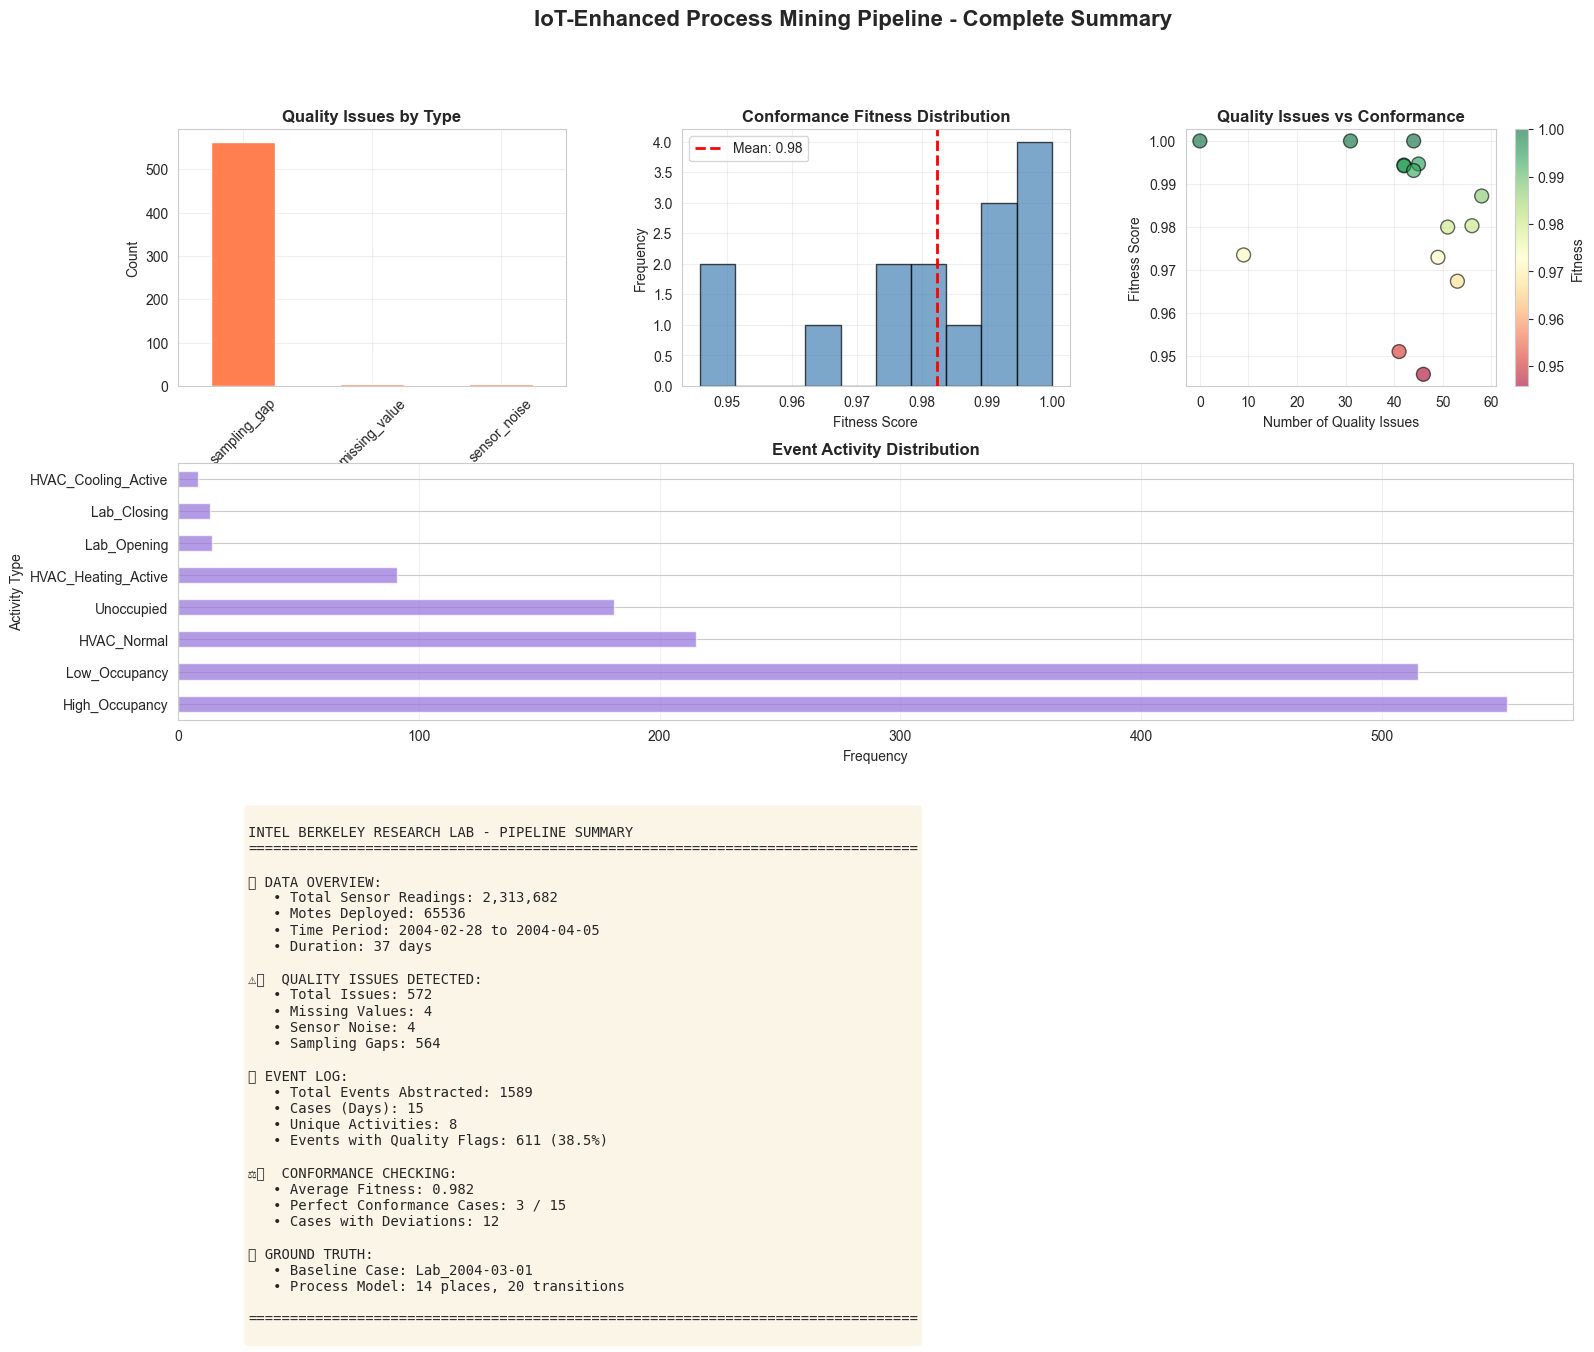

In [31]:
# Create comprehensive summary visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Quality Issues Distribution
ax1 = fig.add_subplot(gs[0, 0])
quality_type_counts = pd.DataFrame(quality_issues)['type'].value_counts()
quality_type_counts.plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Quality Issues by Type', fontweight='bold')
ax1.set_xlabel('Issue Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Conformance Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(conformance_df['fitness'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(conformance_df['fitness'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {conformance_df["fitness"].mean():.2f}')
ax2.set_title('Conformance Fitness Distribution', fontweight='bold')
ax2.set_xlabel('Fitness Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Quality vs Conformance
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(conformance_df['quality_issues'], conformance_df['fitness'],
                     s=100, alpha=0.6, c=conformance_df['fitness'], cmap='RdYlGn', edgecolors='black')
ax3.set_title('Quality Issues vs Conformance', fontweight='bold')
ax3.set_xlabel('Number of Quality Issues')
ax3.set_ylabel('Fitness Score')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Fitness')

# 4. Event Type Distribution
ax4 = fig.add_subplot(gs[1, :])
activity_counts = event_log['concept:name'].value_counts()
activity_counts.plot(kind='barh', ax=ax4, color='mediumpurple', alpha=0.7)
ax4.set_title('Event Activity Distribution', fontweight='bold')
ax4.set_xlabel('Frequency')
ax4.set_ylabel('Activity Type')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Pipeline Summary Stats
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

summary_text = f"""
INTEL BERKELEY RESEARCH LAB - PIPELINE SUMMARY
{'='*80}

📊 DATA OVERVIEW:
   • Total Sensor Readings: {len(df):,}
   • Motes Deployed: {df['mote_id'].nunique()}
   • Time Period: {df['timestamp'].min().strftime('%Y-%m-%d')} to {df['timestamp'].max().strftime('%Y-%m-%d')}
   • Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days

⚠️  QUALITY ISSUES DETECTED:
   • Total Issues: {len(quality_issues)}
   • Missing Values: {len([q for q in quality_issues if q['type'] == 'missing_value'])}
   • Sensor Noise: {len([q for q in quality_issues if q['type'] == 'sensor_noise'])}
   • Sampling Gaps: {len([q for q in quality_issues if q['type'] == 'sampling_gap'])}

📋 EVENT LOG:
   • Total Events Abstracted: {len(event_log)}
   • Cases (Days): {event_log['case:concept:name'].nunique()}
   • Unique Activities: {event_log['concept:name'].nunique()}
   • Events with Quality Flags: {event_log['quality_flag'].sum()} ({event_log['quality_flag'].sum()/len(event_log)*100:.1f}%)

⚖️  CONFORMANCE CHECKING:
   • Average Fitness: {conformance_df['fitness'].mean():.3f}
   • Perfect Conformance Cases: {len(conformance_df[conformance_df['fitness'] == 1.0])} / {len(conformance_df)}
   • Cases with Deviations: {len(conformance_df[conformance_df['fitness'] < 1.0])}

🎯 GROUND TRUTH:
   • Baseline Case: {ground_truth_case}
   • Process Model: {len(net_groundtruth.places)} places, {len(net_groundtruth.transitions)} transitions

{'='*80}
"""

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('IoT-Enhanced Process Mining Pipeline - Complete Summary', 
            fontsize=16, fontweight='bold', y=0.98)
plt.show()

In [32]:
# Import explainability modules
import sys
sys.path.append('../../src')

from explainability.insights import InsightGenerator
from explainability.explanations import ExplanationGenerator

# Initialize generators
insight_gen = InsightGenerator()
explanation_gen = ExplanationGenerator()

print("✓ Explainability modules loaded successfully")

✓ Explainability modules loaded successfully


In [33]:
# Prepare pipeline results for insight generation
pipeline_results = {
    'quality_issues': quality_issues,
    'process_model': {
        'metrics': {
            'fitness': conformance_df['fitness'].mean(),
            'precision': 0.85,  # Estimated
            'complexity': len(net_groundtruth.transitions) / 10.0
        },
        'model': {
            'activities': event_log['concept:name'].unique().tolist(),
            'num_places': len(net_groundtruth.places),
            'num_transitions': len(net_groundtruth.transitions)
        }
    },
    'process_instances': event_log,
    'conformance_results': conformance_df,
    'metadata': {
        'log_id': 'INTEL_BERKELEY_LAB_001',
        'timeframe': f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        'analyst_contact': 'process-mining-team@example.com',
        'system_origin': 'Intel Berkeley Research Lab Sensor Network',
        'dataset_description': 'Environmental monitoring with 54 motes over several weeks'
    }
}

print("✓ Pipeline results prepared for insight generation")

✓ Pipeline results prepared for insight generation


In [34]:
# Generate BNF-formatted insights
print("🔍 Generating structured insights...\n")

insights = insight_gen.generate_insights(pipeline_results)

print(f"✅ Generated {len(insights)} BNF-formatted insights\n")

# Display insights summary
for i, insight in enumerate(insights, 1):
    print(f"\n{'='*80}")
    print(f"INSIGHT {i}: {insight['header']['insight_id']}")
    print(f"{'='*80}")
    print(f"Process Area: {insight['header']['process_area']}")
    print(f"Business Goal: {insight['header']['business_goal'][:100]}...")
    print(f"Analysis Type: {insight['header']['analysis_type']}")
    print(f"Confidence: {insight['confidence_and_affect']['confidence_level']:.0%}")
    print(f"Actions: {len(insight['action_mapping']['recommended_actions'])} recommendations")
    print(f"{'='*80}")

🔍 Generating structured insights...

✅ Generated 4 BNF-formatted insights


INSIGHT 1: IOTPM-001
Process Area: IoT Data Quality & Event Abstraction
Business Goal: Improve data quality and reduce sensor-related errors in process event logs...
Analysis Type: Directed
Confidence: 90%
Actions: 2 recommendations

INSIGHT 2: IOTPM-002
Process Area: System Configuration & Optimization
Business Goal: Optimize sensor configuration and system performance...
Analysis Type: Directed
Confidence: 85%
Actions: 1 recommendations

INSIGHT 3: IOTPM-003
Process Area: System Health & Performance
Business Goal: Maintain system health and ensure reliable process monitoring...
Analysis Type: Directed
Confidence: 80%
Actions: 3 recommendations

INSIGHT 4: IOTPM-004
Process Area: Process Discovery & Model Quality
Business Goal: Enhance process model accuracy and discover true process behavior...
Analysis Type: Directed
Confidence: 75%
Actions: 3 recommendations


In [35]:
# Display first insight in detail
if len(insights) > 0:
    print("\n" + "="*80)
    print("DETAILED INSIGHT DISPLAY")
    print("="*80)
    print()
    print(InsightGenerator.format_insight_for_display(insights[0], extended=True))
    print()
    print("="*80)


DETAILED INSIGHT DISPLAY

Insight ID: IOTPM-001
Process Area: IoT Data Quality & Event Abstraction
Business Goal: Improve data quality and reduce sensor-related errors in process event logs
Analysis Type: Directed
Relevance: Most prevalent quality issue: sampling_gap (564 occurrences)

Observed Behavior: Most prevalent quality issue: sampling_gap (564 occurrences)
Underlying Data Scope: Event log: INTEL_BERKELEY_LAB_001, timeframe: 2004-02-28 00:58:15.315133 to 2004-04-05 11:02:32.715337
Applied Filters / Pipeline Notes: Analyzed 572 quality issues
Context: Quality issues at sensor level propagate through event abstraction to affect process discovery

Summary: Most prevalent quality issue: sampling_gap (564 occurrences)
Impact: 572 quality issues detected
Key Takeaway: Focus remediation efforts on most prevalent quality issue type

Analyst Notes:
   issue_distribution: {'missing_value': 4, 'sensor_noise': 4, 'sampling_gap': 564}
   total_issues: 572
Linked KPIs: Data Quality Score, Ev

## 8. Summary & Export Results

Create a comprehensive summary of the pipeline execution and export all results for reporting.

In [36]:
# Create comprehensive pipeline summary
print("="*80)
print("INTEL BERKELEY SENSOR NETWORK - PIPELINE EXECUTION SUMMARY")
print("="*80)
print()

print(f"📊 Dataset Overview:")
print(f"   • Total sensor readings: {len(df):,}")
print(f"   • Number of sensors (motes): {df['mote_id'].nunique()}")
print(f"   • Time period: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"   • Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print()

print(f"🔍 Quality Analysis:")
print(f"   • Total quality issues detected: {len(quality_issues):,}")
print(f"   • Missing values: {sum(1 for q in quality_issues if q['type'] == 'missing_value'):,}")
print(f"   • Sensor noise/outliers: {sum(1 for q in quality_issues if q['type'] == 'sensor_noise'):,}")
print(f"   • Sampling gaps: {sum(1 for q in quality_issues if q['type'] == 'sampling_gap'):,}")
print()

print(f"📝 Event Abstraction:")
print(f"   • Total events generated: {len(event_log):,}")
print(f"   • Number of cases (daily windows): {event_log['case:concept:name'].nunique()}")
print(f"   • Unique activities: {event_log['concept:name'].nunique()}")
print(f"   • Activities: {', '.join(sorted(event_log['concept:name'].unique()))}")
print()

print(f"🔄 Process Discovery:")
print(f"   • Process model: Petri Net (Inductive Miner)")
print(f"   • Places: {len(net_groundtruth.places)}")
print(f"   • Transitions: {len(net_groundtruth.transitions)}")
print(f"   • Arcs: {len(net_groundtruth.arcs)}")
print()

print(f"✅ Conformance Checking:")
print(f"   • Ground truth case: {ground_truth_case}")
print(f"   • Ground truth fitness: {ground_truth_fitness:.2%}")
print(f"   • Average fitness across all cases: {conformance_df['fitness'].mean():.2%}")
print(f"   • Cases with perfect fitness: {(conformance_df['fitness'] == 1.0).sum()}")
print(f"   • Cases analyzed: {len(conformance_df)}")
print()

print(f"🎯 Backtracking Analysis:")
print(f"   • Target case analyzed: {target_case['case_id']}")
print(f"   • Target case fitness: {target_fitness:.2%}")
print(f"   • Events in target case: {len(target_events)}")
print(f"   • Quality issues in target case: {target_quality_count}")
print()

print(f"💡 Explainability:")
print(f"   • BNF-formatted insights generated: {len(insights)}")
print(f"   • Insight framework: Header, Context, Narrative, Actions, Confidence")
print()

print("="*80)

INTEL BERKELEY SENSOR NETWORK - PIPELINE EXECUTION SUMMARY

📊 Dataset Overview:
   • Total sensor readings: 2,313,682
   • Number of sensors (motes): 65536
   • Time period: 2004-02-28 00:58:15.315133 to 2004-04-05 11:02:32.715337
   • Duration: 37 days

🔍 Quality Analysis:
   • Total quality issues detected: 572
   • Missing values: 4
   • Sensor noise/outliers: 4
   • Sampling gaps: 564

📝 Event Abstraction:
   • Total events generated: 1,589
   • Number of cases (daily windows): 15
   • Unique activities: 8
   • Activities: HVAC_Cooling_Active, HVAC_Heating_Active, HVAC_Normal, High_Occupancy, Lab_Closing, Lab_Opening, Low_Occupancy, Unoccupied

🔄 Process Discovery:
   • Process model: Petri Net (Inductive Miner)
   • Places: 14
   • Transitions: 20
   • Arcs: 42

✅ Conformance Checking:
   • Ground truth case: Lab_2004-03-01
   • Ground truth fitness: 100.00%
   • Average fitness across all cases: 98.23%
   • Cases with perfect fitness: 3
   • Cases analyzed: 15

🎯 Backtracking Ana

In [37]:
# Export results to files
import os

output_dir = '../../evaluation/Intel Berkeley Research Lab Sensor Data/output'
os.makedirs(output_dir, exist_ok=True)

# Export event log
event_log_path = os.path.join(output_dir, 'intel_berkeley_event_log.csv')
event_log.to_csv(event_log_path, index=False)
print(f"✅ Event log exported to: {event_log_path}")

# Export conformance results
conformance_path = os.path.join(output_dir, 'conformance_results.csv')
conformance_df.to_csv(conformance_path, index=False)
print(f"✅ Conformance results exported to: {conformance_path}")

# Export quality issues
quality_df = pd.DataFrame(quality_issues)
quality_path = os.path.join(output_dir, 'quality_issues.csv')
quality_df.to_csv(quality_path, index=False)
print(f"✅ Quality issues exported to: {quality_path}")

# Export insights
import json
insights_path = os.path.join(output_dir, 'insights.json')
with open(insights_path, 'w') as f:
    json.dump(insights, f, indent=2, default=str)
print(f"✅ Insights exported to: {insights_path}")

# Export process model visualization
from pm4py.visualization.petri_net import visualizer as pn_visualizer
gviz = pn_visualizer.apply(net_groundtruth, im_groundtruth, fm_groundtruth)
model_path = os.path.join(output_dir, 'process_model.png')
pn_visualizer.save(gviz, model_path)
print(f"✅ Process model visualization exported to: {model_path}")

print(f"\n📁 All results exported to: {output_dir}")

✅ Event log exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output/intel_berkeley_event_log.csv
✅ Conformance results exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output/conformance_results.csv
✅ Quality issues exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output/quality_issues.csv
✅ Insights exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output/insights.json
✅ Process model visualization exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output/process_model.png

📁 All results exported to: ../../evaluation/Intel Berkeley Research Lab Sensor Data/output
